In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned CSV data
df = pd.read_csv(
    "C:\\Users\\viktoriya.haiduk\\Desktop\\MIT\\ET6-CDSP-group-03-repo\\1_datasets\\data\\clean_datasets\\infrastructure_damaged_clean.csv"
)


# Display the column names
print(df.columns)

# Show the first 5 rows of the dataset
df.head()

Index(['report_date', 'civic_ext_destroyed', 'edu_ext_destroyed',
       'edu_ext_damaged', 'mosques_ext_destroyed', 'mosques_ext_damaged',
       'churches_ext_destroyed', 'residential_ext_destroyed',
       'residential_destroyed', 'civic_destroyed', 'edu_destroyed',
       'edu_damaged', 'mosques_destroyed', 'mosques_damaged',
       'churches_destroyed'],
      dtype='object')


,report_date,civic_ext_destroyed,edu_ext_destroyed,edu_ext_damaged,mosques_ext_destroyed,mosques_ext_damaged,churches_ext_destroyed,residential_ext_destroyed,residential_destroyed,civic_destroyed,edu_destroyed,edu_damaged,mosques_destroyed,mosques_damaged,churches_destroyed
0,2023-10-07,5,1,15,2,4.0,0,80,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2023-10-08,11,1,30,4,8.0,0,159,159.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2023-10-09,16,2,45,6,12.0,0,790,790.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2023-10-10,22,2,60,8,17.0,0,1009,1009.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2023-10-11,27,3,75,10,21.0,0,2835,2835.0,27.0,3.0,75.0,10.0,0.0,0.0


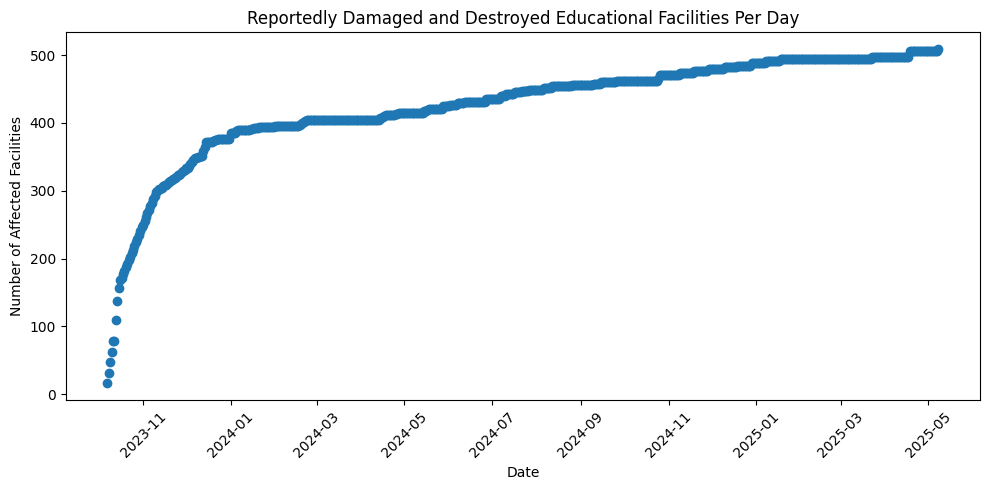

In [10]:
# Convert the 'report_date' column to datetime format
df['report_date'] = pd.to_datetime(df['report_date'])

# Create a new column with the sum of destroyed and damaged education facilities
df['edu_total_ext_impact'] = df['edu_ext_destroyed'] + df['edu_ext_damaged']

# Group by date and sum the total impact per day
daily_sum = df.groupby(df['report_date'].dt.date)['edu_total_ext_impact'].sum()

# Plot as scatter plot
plt.figure(figsize=(10, 5))
plt.scatter(daily_sum.index, daily_sum.values)

plt.title('Reportedly Damaged and Destroyed Educational Facilities Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Affected Facilities')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


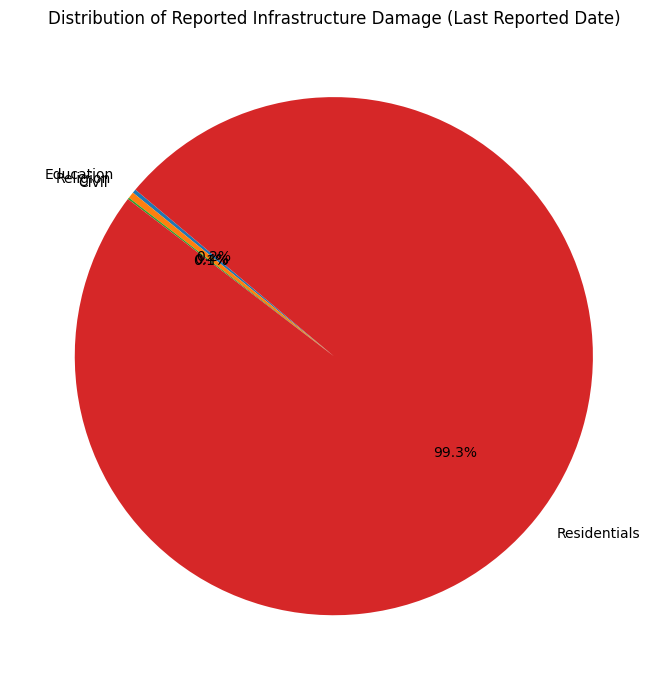

In [12]:
# Select the last row of the DataFrame
last_row = df.iloc[-1]

# Calculate values for each category
education = last_row['edu_ext_destroyed'] + last_row['edu_ext_damaged']
religion = (
    last_row['mosques_ext_destroyed'] +
    last_row['mosques_ext_damaged'] +
    last_row['churches_ext_destroyed']
)
civil = last_row['civic_ext_destroyed']
residentials = last_row['residential_ext_destroyed']

# Create data and labels
values = [education, religion, civil, residentials]
labels = ['Education', 'Religion', 'Civil', 'Residentials']

# Plot pie chart
plt.figure(figsize=(7, 7))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Reported Infrastructure Damage (Last Reported Date)')
plt.tight_layout()
plt.show()


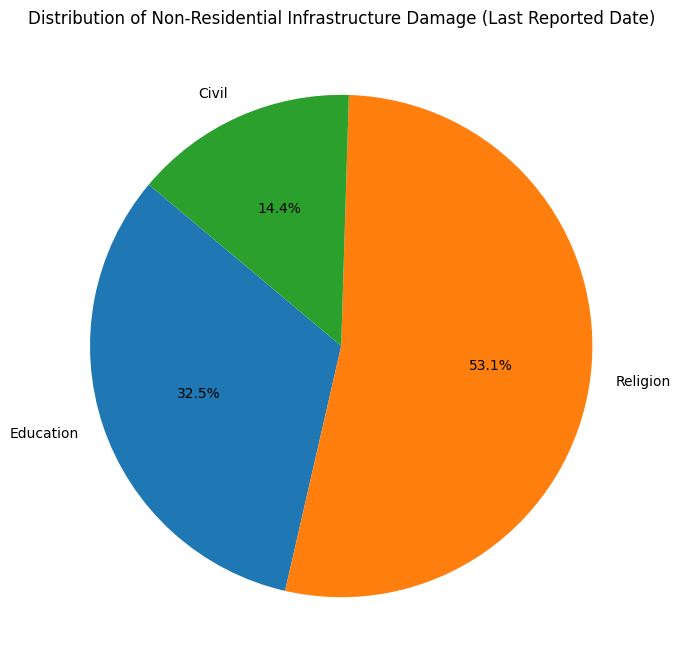

In [13]:
# Select the last row of the DataFrame
last_row = df.iloc[-1]

# Calculate values for each category (excluding residentials)
education = last_row['edu_ext_destroyed'] + last_row['edu_ext_damaged']
religion = (
    last_row['mosques_ext_destroyed'] +
    last_row['mosques_ext_damaged'] +
    last_row['churches_ext_destroyed']
)
civil = last_row['civic_ext_destroyed']

# Create data and labels
values = [education, religion, civil]
labels = ['Education', 'Religion', 'Civil']

# Plot pie chart
plt.figure(figsize=(7, 7))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Non-Residential Infrastructure Damage (Last Reported Date)')
plt.tight_layout()
plt.show()


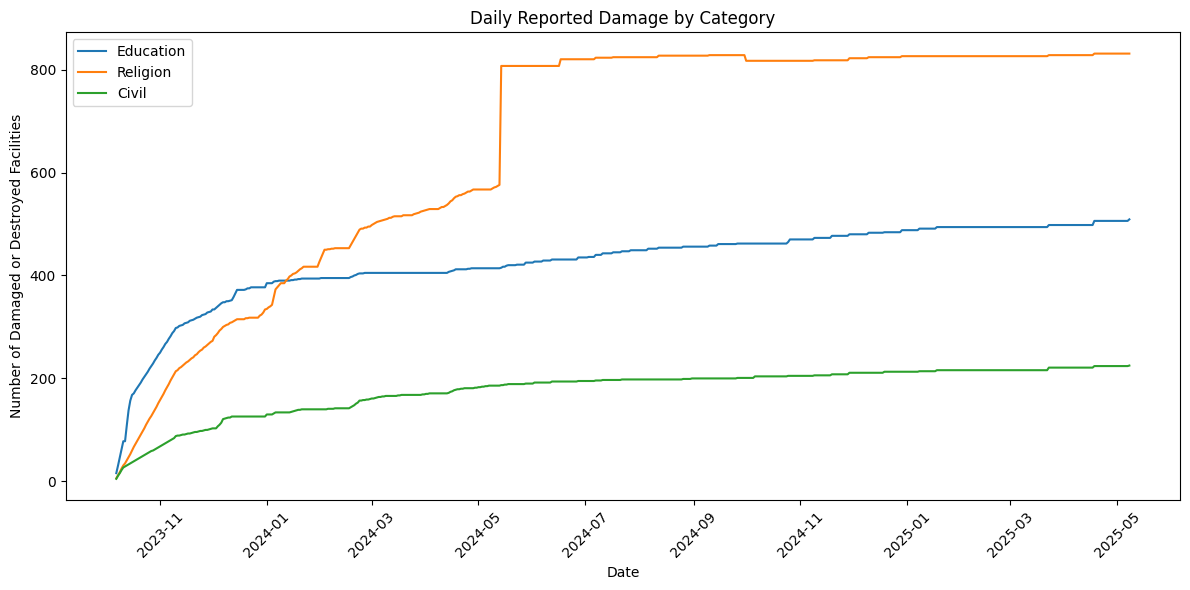

In [15]:
# Ensure 'report_date' is in datetime format
df['report_date'] = pd.to_datetime(df['report_date'])

# Calculate total for each category per row
df['education'] = df['edu_ext_destroyed'] + df['edu_ext_damaged']
df['religion'] = (
    df['mosques_ext_destroyed'] +
    df['mosques_ext_damaged'] +
    df['churches_ext_destroyed']
)
df['civil'] = df['civic_ext_destroyed']

# Group by date and sum each category
daily_summary = df.groupby(df['report_date'].dt.date)[['education', 'religion', 'civil']].sum()

# Plot the line chart
plt.figure(figsize=(12, 6))
plt.plot(daily_summary.index, daily_summary['education'], label='Education')
plt.plot(daily_summary.index, daily_summary['religion'], label='Religion')
plt.plot(daily_summary.index, daily_summary['civil'], label='Civil')

plt.title('Daily Reported Damage by Category')
plt.xlabel('Date')
plt.ylabel('Number of Damaged or Destroyed Facilities')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


Pearson correlation between education and civil damage: 0.97


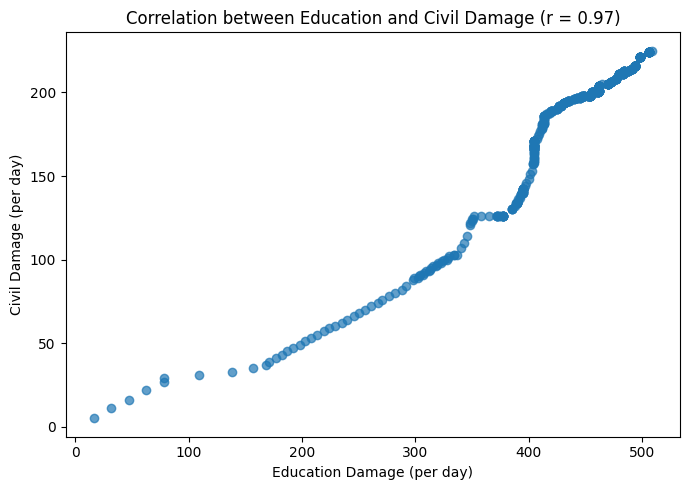

In [16]:
# Ensure 'education' and 'civil' columns are calculated
df['education'] = df['edu_ext_destroyed'] + df['edu_ext_damaged']
df['civil'] = df['civic_ext_destroyed']

# Group by date and sum values per day
daily = df.groupby(df['report_date'].dt.date)[['education', 'civil']].sum()

# Calculate Pearson correlation coefficient
correlation = daily['education'].corr(daily['civil'])
print(f"Pearson correlation between education and civil damage: {correlation:.2f}")

# Plot scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(daily['education'], daily['civil'], alpha=0.7)
plt.title(f'Correlation between Education and Civil Damage (r = {correlation:.2f})')
plt.xlabel('Education Damage (per day)')
plt.ylabel('Civil Damage (per day)')
plt.tight_layout()
plt.show()


Pearson correlation between education and religion damage: 0.90


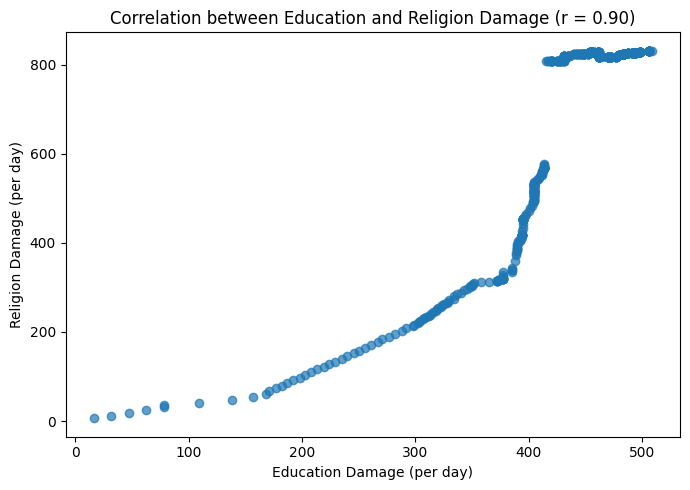

In [17]:
# Ensure 'education' column is calculated
df['education'] = df['edu_ext_destroyed'] + df['edu_ext_damaged']

# Calculate 'religion' column
df['religion'] = (
    df['mosques_ext_destroyed'] +
    df['mosques_ext_damaged'] +
    df['churches_ext_destroyed']
)

# Group by date and sum values per day
daily = df.groupby(df['report_date'].dt.date)[['education', 'religion']].sum()

# Calculate Pearson correlation coefficient
correlation = daily['education'].corr(daily['religion'])
print(f"Pearson correlation between education and religion damage: {correlation:.2f}")

# Plot scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(daily['education'], daily['religion'], alpha=0.7)
plt.title(f'Correlation between Education and Religion Damage (r = {correlation:.2f})')
plt.xlabel('Education Damage (per day)')
plt.ylabel('Religion Damage (per day)')
plt.tight_layout()
plt.show()


C:\Users\viktoriya.haiduk\AppData\Local\Temp\ipykernel_19884\30940136.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_cumulative = daily_cumulative.resample('M').max()


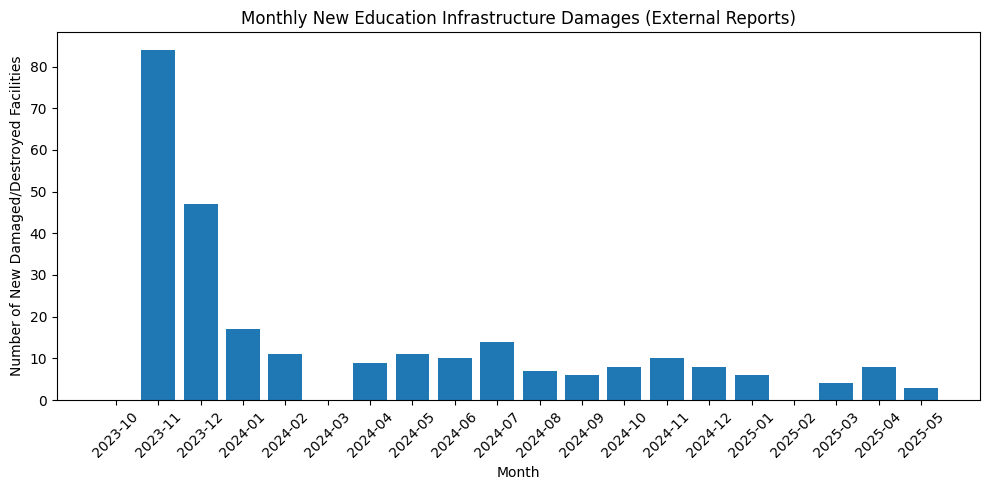

In [20]:
# Ensure 'report_date' is datetime
df['report_date'] = pd.to_datetime(df['report_date'])

# Calculate cumulative total for education
df['education_total'] = df['edu_ext_destroyed'] + df['edu_ext_damaged']

# Get max cumulative value per day
daily_cumulative = df.groupby(df['report_date'].dt.date)['education_total'].max()

# Convert to datetime index
daily_cumulative.index = pd.to_datetime(daily_cumulative.index)

# Resample to monthly max (cumulative data)
monthly_cumulative = daily_cumulative.resample('M').max()

# Calculate monthly new damages
monthly_new = monthly_cumulative.diff().fillna(0)

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(monthly_new.index.strftime('%Y-%m'), monthly_new.values)

plt.title('Monthly New Education Infrastructure Damages (External Reports)')
plt.xlabel('Month')
plt.ylabel('Number of New Damaged/Destroyed Facilities')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [21]:
# Ensure 'report_date' is in datetime format
df['report_date'] = pd.to_datetime(df['report_date'])

# Calculate cumulative total for education
df['education_total'] = df['edu_ext_destroyed'] + df['edu_ext_damaged']

# Group by day and get maximum cumulative value per day
daily_cumulative = df.groupby(df['report_date'].dt.date)['education_total'].max()

# Compute daily new values (difference between days)
daily_new = daily_cumulative.diff().fillna(0)

# Sort and display top 10 days with highest new education damages
top_10_days = daily_new.sort_values(ascending=False).head(10)

# Display result
print("Top 10 Days with Most Newly Reported Education Infrastructure Damages:")
display(top_10_days)


Top 10 Days with Most Newly Reported Education Infrastructure Damages:


report_date
2023-10-13    31.0
2023-10-14    29.0
2023-10-15    19.0
2023-10-09    16.0
2023-10-11    16.0
2023-10-10    15.0
2023-10-08    15.0
2023-10-16    11.0
2024-01-01     8.0
2025-04-18     8.0
Name: education_total, dtype: float64